# Задачи по работе с данными с использованием MySQL и Python
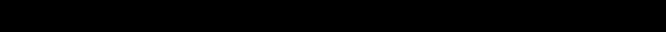

В этом задании вам нужно изучить файлы с табличными данными и ответить на вопросы.
В архиве purchases.rar находятся четыре датасета: purchases.csv, products.csv, raw_purchases.csv и raw_products.csv.
Вам необходимо загрузить датасеты purchases.csv и products.csv в Python или в MySQL (можете выбрать другую СУБД) и ответить на вопросы. Содержание каждого из файлов:
purchases.csv - данные по продажам, где:
* lastsignTrafficSource - источник данных
* purchaseID - id покупки
* purchaseRevenue - стоимость покупки
* purchaseDateTime - дата и время совершения покупки

products.csv - данные по товарам, где:
* productsPurchaseID - id покупки, в которой был куплен товар
* productID - id товара в покупке
* productsPrice - стоимость товара
Для первой части задания можно выбрать только один из способов выполнения: в MySQL или Python.
- Для Python создайте ipynb файл и загрузите в него датасеты, используя библиотеку pandas.
- Для MySQL создайте две таблицы для каждого из датасетов. Приложите SQL-запрос для создания каждой из таблиц.
Ниже записаны вопросы, на которые можно ответить любым из способов. В ответе приложите их решение (либо запрос sql, либо код python):
1. В каком из источников было куплено больше всего товаров?
2. Какое максимальное количество уникальных товаров было куплено за один день?
3. В какой день было совершено меньше всего покупок?
4. Какое максимальное падение количества покупок по источнику organic было от дня ко дню? Укажите в процентах.
Учитывайте, что в данных и могут быть неточности и ошибки, выбросы и аномалии, а условия задачи могут быть неполными. Если вы обнаружите некорректные, на ваш взгляд, данные или ошибки в условиях, опишите возможную причину их возникновения, и как, по-вашему, с ними стоит поступить.

Следующие задачи выполните в Python. Решение задач пропишите в ipynb файле, где будут код и графики:
1.	Постройте линейный график изменения количества покупок от дня ко дню за месяц. Осью X будет дата, осью Y - изменение количества покупок. Изменение количества покупок укажите в процентах.
2.	Постройте линейный график распределения количества купленных товаров стоимостью больше 2000 рублей по дням. Осью X будет дата (день, месяц, год), осью Y количество товаров.
3.	Постройте столбчатую диаграмму средней стоимости товара в покупке по всем источникам. Осью Y будет средняя стоимость товара, каждый столбец будет соответствовать одному источнику.
4.	*(Усложнённая задача) Преобразуйте необработанные данные из источников raw_purchases.csv и raw_products.csv в вид, соответствующий исходным данным для задания.

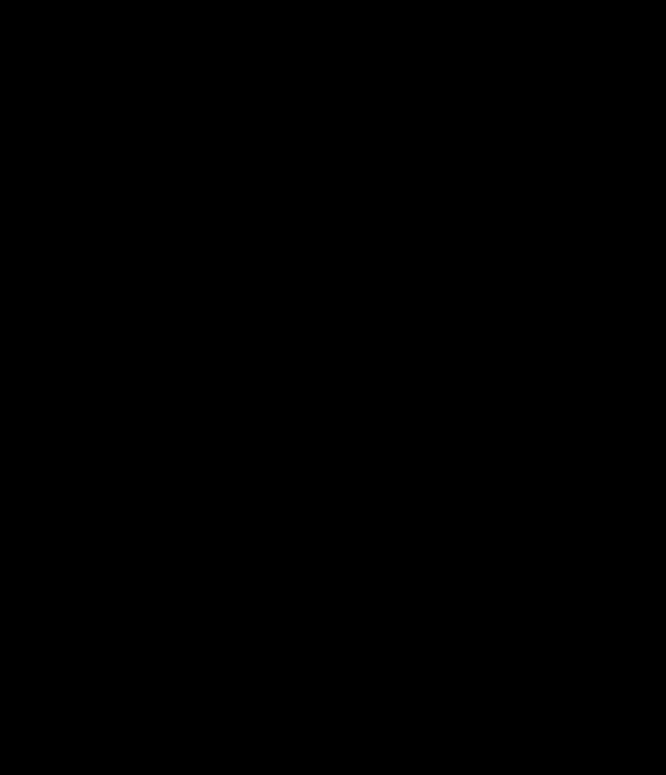

In [68]:
import ast

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import ast
from narwhals import read_csv

In [2]:
products = pd.read_csv('products.csv')
products

,productsPurchaseID,productsID,productsPrice
0,60323068,58627,4590.0
1,60323068,137958,0.0
2,60324684,28543,3391.0
3,60324684,137958,0.0
4,60329108,1921,16310.0
...,...,...,...
20764,60327669,289514,324.0
20765,60327669,286864,0.0
20766,60327669,137958,0.0
20767,60327669,294093,0.0


In [3]:
products.dtypes

productsPurchaseID      int64
productsID              int64
productsPrice         float64
dtype: object

In [4]:
purchases = pd.read_csv('purchases.csv', parse_dates=['purchaseDateTime'])
purchases

,lastsignTrafficSource,purchaseID,purchaseRevenue,purchaseDateTime
0,organic,60337498,2845.0,2025-05-27 10:19:03
1,organic,60335988,7830.0,2025-05-24 16:30:01
2,ad,60334562,9319.0,2025-05-22 01:59:54
3,direct,60336983,6889.0,2025-05-26 12:11:20
4,direct,60336989,4549.0,2025-05-26 12:16:08
...,...,...,...,...
6457,ad,60332870,4436.0,2025-05-19 10:53:39
6458,referral,60335643,9900.0,2025-05-23 20:13:04
6459,ad,60330154,4960.0,2025-05-14 23:26:30
6460,ad,60323344,1172.0,2025-05-04 20:27:56


In [5]:
purchases.dtypes

lastsignTrafficSource               str
purchaseID                        int64
purchaseRevenue                 float64
purchaseDateTime         datetime64[us]
dtype: object

In [6]:
purchases.info()

<class 'pandas.DataFrame'>
RangeIndex: 6462 entries, 0 to 6461
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   lastsignTrafficSource  6462 non-null   str           
 1   purchaseID             6462 non-null   int64         
 2   purchaseRevenue        6462 non-null   float64       
 3   purchaseDateTime       6462 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 202.1 KB


In [7]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 20769 entries, 0 to 20768
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   productsPurchaseID  20769 non-null  int64  
 1   productsID          20769 non-null  int64  
 2   productsPrice       20769 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 486.9 KB


In [8]:
purchases.shape, products.shape

((6462, 4), (20769, 3))

In [9]:
merged = purchases.merge(products, left_on='purchaseID', right_on = 'productsPurchaseID')

merged.head()

,lastsignTrafficSource,purchaseID,purchaseRevenue,purchaseDateTime,productsPurchaseID,productsID,productsPrice
0,organic,60337498,2845.0,2025-05-27 10:19:03,60337498,287784,2655.0
1,organic,60337498,2845.0,2025-05-27 10:19:03,60337498,154392,0.0
2,organic,60335988,7830.0,2025-05-24 16:30:01,60335988,291743,7830.0
3,organic,60335988,7830.0,2025-05-24 16:30:01,60335988,137958,0.0
4,organic,60335988,7830.0,2025-05-24 16:30:01,60335988,294093,0.0


In [10]:
traffic_top = merged.groupby('lastsignTrafficSource') \
    .size().sort_values(ascending=False)
traffic_top

lastsignTrafficSource
ad           8590
organic      7485
referral     1933
direct       1649
email         667
internal      360
messenger      42
social         32
recommend      11
dtype: int64

Проверка, есть ли нулевые значения

In [11]:
products['productsPrice'].value_counts().head()

productsPrice
0.0       10671
90.0         68
2100.0       53
2160.0       53
1950.0       45
Name: count, dtype: int64

In [12]:
purchases['purchaseRevenue'].value_counts().sort_values(ascending=True)

purchaseRevenue
2872.0      1
4013.0      1
1900.0      1
9846.0      1
7688.0      1
           ..
9300.0     26
280.0      30
6760.0     32
14900.0    34
10850.0    36
Name: count, Length: 3561, dtype: int64

In [13]:
traffic_top_without_zero_purch = merged.query('productsPrice != 0') \
    .groupby('lastsignTrafficSource') \
    .size().sort_values(ascending=False)

traffic_top_without_zero_purch

lastsignTrafficSource
ad           4014
organic      3747
referral     1020
direct        756
email         331
internal      188
messenger      19
social         18
recommend       5
dtype: int64

Вопрос 1. В каком из источников было куплено больше всего товаров?

Ответ: Больше всего товаров было куплено с источника 'ad'
1. Без исключения нулевых значений было куплено 8590 товаров.
2. С доп проверкой и временным исключением нулевых значений вышло 4014 товаров.


#### Какое максимальное количество уникальных товаров было куплено за один день?

In [14]:
purchases['Date'] = purchases['purchaseDateTime'].dt.date

purchases

,lastsignTrafficSource,purchaseID,purchaseRevenue,purchaseDateTime,Date
0,organic,60337498,2845.0,2025-05-27 10:19:03,2025-05-27
1,organic,60335988,7830.0,2025-05-24 16:30:01,2025-05-24
2,ad,60334562,9319.0,2025-05-22 01:59:54,2025-05-22
3,direct,60336983,6889.0,2025-05-26 12:11:20,2025-05-26
4,direct,60336989,4549.0,2025-05-26 12:16:08,2025-05-26
...,...,...,...,...,...
6457,ad,60332870,4436.0,2025-05-19 10:53:39,2025-05-19
6458,referral,60335643,9900.0,2025-05-23 20:13:04,2025-05-23
6459,ad,60330154,4960.0,2025-05-14 23:26:30,2025-05-14
6460,ad,60323344,1172.0,2025-05-04 20:27:56,2025-05-04


In [15]:
# объединим еще раз тк добавили новую колонку в purchases
merged = purchases.merge(products, left_on='purchaseID', right_on = 'productsPurchaseID')

merged.head()

,lastsignTrafficSource,purchaseID,purchaseRevenue,purchaseDateTime,Date,productsPurchaseID,productsID,productsPrice
0,organic,60337498,2845.0,2025-05-27 10:19:03,2025-05-27,60337498,287784,2655.0
1,organic,60337498,2845.0,2025-05-27 10:19:03,2025-05-27,60337498,154392,0.0
2,organic,60335988,7830.0,2025-05-24 16:30:01,2025-05-24,60335988,291743,7830.0
3,organic,60335988,7830.0,2025-05-24 16:30:01,2025-05-24,60335988,137958,0.0
4,organic,60335988,7830.0,2025-05-24 16:30:01,2025-05-24,60335988,294093,0.0


In [16]:
top_unique_products = merged.groupby('Date')['productsID'].nunique() \
    .sort_values(ascending=False)

top_unique_products.head()

Date
2025-05-14    413
2025-05-20    379
2025-05-13    375
2025-05-12    365
2025-05-15    354
Name: productsID, dtype: int64

Ответ на вопрос 2:
- Максимальное количество уникальных товаров, купленных за один день является 413 товаров 14 мая 2025 года

В описании структуры products.csv указан столбец productID, однако в предоставленном датасете фактическое название столбца является productsID. В расчетах использовалось фактическое название


#### В какой день было совершено меньше всего покупок?


In [17]:
merged['Date'].value_counts().sort_values()

# отсюда видно, что 1 июня может оказаться датой, в котором совершено меньше всего покупок, но проверим дополнительно

Date
2025-06-01      1
2025-05-24    440
2025-05-09    491
2025-05-19    526
2025-05-23    533
2025-05-17    537
2025-05-27    544
2025-05-21    578
2025-05-03    580
2025-05-02    581
2025-05-22    582
2025-05-25    586
2025-05-31    614
2025-05-26    622
2025-05-18    632
2025-05-04    636
2025-05-11    636
2025-05-16    648
2025-05-28    662
2025-05-29    686
2025-05-01    687
2025-05-10    712
2025-05-15    737
2025-05-12    752
2025-05-30    769
2025-05-08    778
2025-05-14    822
2025-05-20    841
2025-05-05    852
2025-05-06    880
2025-05-07    894
2025-05-13    930
Name: count, dtype: int64

In [18]:
less_purchases = merged.groupby('Date')['purchaseID'].nunique().sort_values()
less_purchases.head()

Date
2025-06-01      1
2025-05-09    137
2025-05-24    141
2025-05-31    157
2025-05-03    165
Name: purchaseID, dtype: int64

Ответ на 3 вопрос:
- меньше всего покупок было совершено 1 июня 2025 года

Но, если датасет предполагает выгрузку только за май, то меньше всего покупок среди майских дат является 9 мая 2025 года

#### Какое максимальное падение количества покупок по источнику organic было от дня ко дню? Укажите в процентах.

In [19]:
percentage_df = (merged.query('lastsignTrafficSource == "organic"') \
    .groupby('Date')['purchaseID'].nunique()) \
    .pct_change().sort_values().reset_index()

percentage_df.style.format({'purchaseID': '{:.3%}'})

,Date,purchaseID
0,2025-06-01,-98.718%
1,2025-05-17,-29.885%
2,2025-05-03,-27.381%
3,2025-05-09,-23.684%
4,2025-05-30,-22.093%
5,2025-05-19,-21.053%
6,2025-05-23,-20.000%
7,2025-05-14,-13.402%
8,2025-05-26,-12.644%
9,2025-05-22,-12.371%


In [20]:
percentage_df['Date'] = pd.to_datetime(percentage_df['Date'])
percentage_df.dtypes

Date          datetime64[s]
purchaseID          float64
dtype: object

(array([20209., 20213., 20217., 20221., 20225., 20229., 20233., 20237.,
        20240.]),
 [Text(20209.0, 0, '2025-05-01'),
  Text(20213.0, 0, '2025-05-05'),
  Text(20217.0, 0, '2025-05-09'),
  Text(20221.0, 0, '2025-05-13'),
  Text(20225.0, 0, '2025-05-17'),
  Text(20229.0, 0, '2025-05-21'),
  Text(20233.0, 0, '2025-05-25'),
  Text(20237.0, 0, '2025-05-29'),
  Text(20240.0, 0, '2025-06-01')])

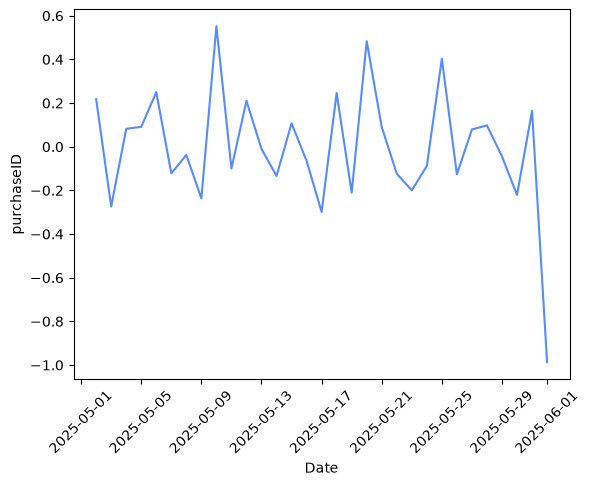

In [21]:


sns.lineplot(percentage_df, x = percentage_df.Date, y = percentage_df.purchaseID)
plt.rc('ytick', labelsize = 8)
plt.rc('xtick', labelsize = 8)
plt.xticks(rotation = 45)
# графика для наглядности

Ответ на вопрос 4:
- максимальное падение фиксируется на 1 июня 2025 года, НО это та же аномалия и если датасет предполагал майские даты, то максимальное падение будет на 17 мая 2025 года

----------------------------------------------------

Теперь перейдем к задачам, где будут код и графики:

- Постройте линейный график изменения количества покупок от дня ко дню за месяц. Осью X будет дата, осью Y - изменение количества покупок. Изменение количества покупок укажите в процентах.
- Постройте линейный график распределения количества купленных товаров стоимостью больше 2000 рублей по дням. Осью X будет дата (день, месяц, год), осью Y количество товаров.
- Постройте столбчатую диаграмму средней стоимости товара в покупке по всем источникам. Осью Y будет средняя стоимость товара, каждый столбец будет соответствовать одному источнику.
- *(Усложнённая задача) Преобразуйте необработанные данные из источников raw_purchases.csv и raw_products.csv в вид, соответствующий исходным данным для задания.

#### Постройте линейный график изменения количества покупок от дня ко дню за месяц. Осью X будет дата, осью Y - изменение количества покупок. Изменение количества покупок укажите в процентах.

In [22]:
percentage_with_all_traffic = (merged.groupby('Date')['purchaseID'].nunique()) \
    .pct_change().sort_values().reset_index()

percentage_with_all_traffic.style.format({'purchaseID': '{:.3%}'})

,Date,purchaseID
0,2025-06-01,-99.363%
1,2025-05-09,-23.034%
2,2025-05-08,-21.930%
3,2025-05-24,-19.429%
4,2025-05-23,-18.605%
5,2025-05-17,-18.534%
6,2025-05-31,-13.736%
7,2025-05-16,-12.782%
8,2025-05-03,-12.698%
9,2025-05-14,-11.950%


(array([20209., 20213., 20217., 20221., 20225., 20229., 20233., 20237.,
        20240.]),
 [Text(20209.0, 0, '2025-05-01'),
  Text(20213.0, 0, '2025-05-05'),
  Text(20217.0, 0, '2025-05-09'),
  Text(20221.0, 0, '2025-05-13'),
  Text(20225.0, 0, '2025-05-17'),
  Text(20229.0, 0, '2025-05-21'),
  Text(20233.0, 0, '2025-05-25'),
  Text(20237.0, 0, '2025-05-29'),
  Text(20240.0, 0, '2025-06-01')])

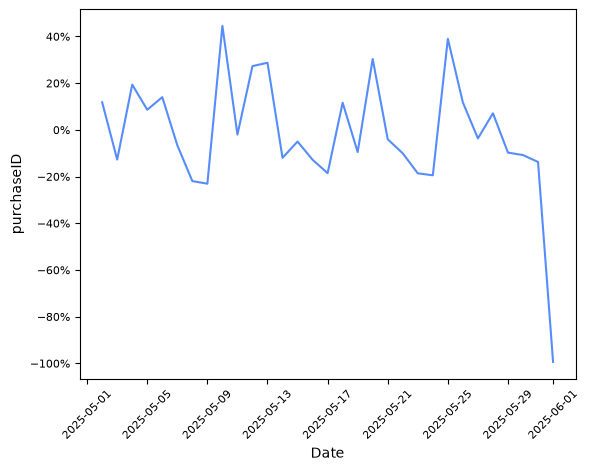

In [25]:
sns.lineplot(percentage_with_all_traffic, x = percentage_with_all_traffic.Date, y = percentage_with_all_traffic.purchaseID)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.rc('ytick', labelsize = 8)
plt.rc('xtick', labelsize = 8)
plt.xticks(rotation = 45)

#### Постройте линейный график распределения количества купленных товаров стоимостью больше 2000 рублей по дням. Осью X будет дата (день, месяц, год), осью Y количество товаров.

In [26]:
products_above_2000 = merged.query('productsPrice > 2000') \
    .groupby('Date',as_index=False)['productsID'] \
    .count()
products_above_2000

,Date,productsID
0,2025-05-01,196
1,2025-05-02,201
2,2025-05-03,199
3,2025-05-04,209
4,2025-05-05,227
5,2025-05-06,265
6,2025-05-07,249
7,2025-05-08,203
8,2025-05-09,157
9,2025-05-10,220


(array([20209., 20213., 20217., 20221., 20225., 20229., 20233., 20237.,
        20240.]),
 [Text(20209.0, 0, '2025-05-01'),
  Text(20213.0, 0, '2025-05-05'),
  Text(20217.0, 0, '2025-05-09'),
  Text(20221.0, 0, '2025-05-13'),
  Text(20225.0, 0, '2025-05-17'),
  Text(20229.0, 0, '2025-05-21'),
  Text(20233.0, 0, '2025-05-25'),
  Text(20237.0, 0, '2025-05-29'),
  Text(20240.0, 0, '2025-06-01')])

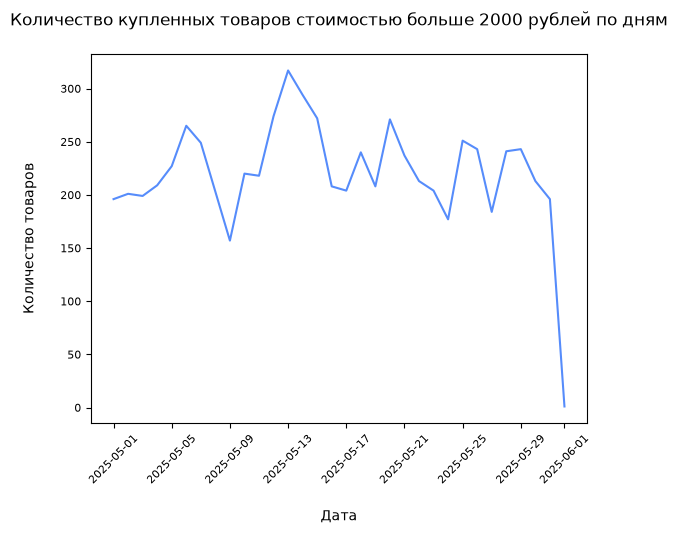

In [33]:

sns.lineplot(products_above_2000, x=products_above_2000.Date, y='productsID')
plt.xlabel('\nДата')
plt.ylabel('Количество товаров\n')
plt.title('Количество купленных товаров стоимостью больше 2000 рублей по дням\n')
plt.xticks(rotation=45)

#### Постройте столбчатую диаграмму средней стоимости товара в покупке по всем источникам. Осью Y будет средняя стоимость товара, каждый столбец будет соответствовать одному источнику.

In [37]:
avg_price = merged.groupby('lastsignTrafficSource', as_index=False)['productsPrice'].mean() \
    .sort_values('productsPrice', ascending=False)

avg_price

,lastsignTrafficSource,productsPrice
7,referral,3010.067770
5,organic,2790.581563
1,direct,2660.836264
0,ad,2636.252154
3,internal,2306.291667
6,recommend,2205.000000
2,email,2098.502249
4,messenger,1964.309524
8,social,1509.250000


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'referral'),
  Text(1, 0, 'organic'),
  Text(2, 0, 'direct'),
  Text(3, 0, 'ad'),
  Text(4, 0, 'internal'),
  Text(5, 0, 'recommend'),
  Text(6, 0, 'email'),
  Text(7, 0, 'messenger'),
  Text(8, 0, 'social')])

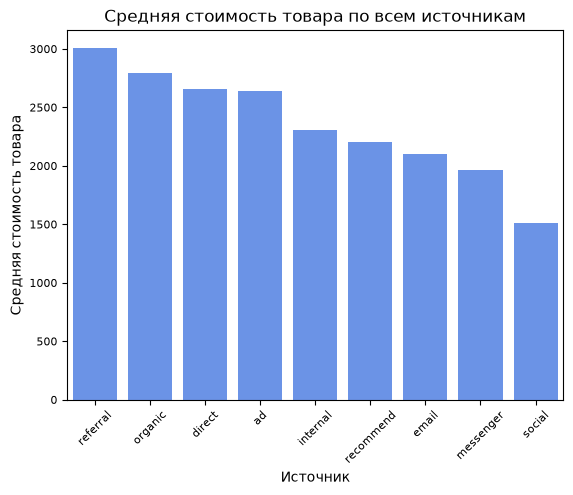

In [44]:
sns.barplot(avg_price, x=avg_price.lastsignTrafficSource, y= avg_price.productsPrice)
plt.xlabel('Источник')
plt.ylabel('Средняя стоимость товара')
plt.title('Средняя стоимость товара по всем источникам')
plt.xticks(rotation=45)

У нас много товаров с нулевой ценой, поэтому дополнительно проверим насколько средняя стоимость может быть занижена, поэтому проведем дополнительную проверку влияния нулевых значений

In [45]:
merged['productsPrice'].describe()

count     20769.000000
mean       2702.301844
std        5357.956254
min           0.000000
25%           0.000000
50%           0.000000
75%        3465.000000
max      106968.000000
Name: productsPrice, dtype: float64

In [46]:
(merged['productsPrice'] == 0).mean()

np.float64(0.5137945977177524)

In [47]:
avg_price_without_zero = merged.query('productsPrice != 0') \
    .groupby('lastsignTrafficSource', as_index=False)['productsPrice'].mean() \
    .sort_values('productsPrice', ascending=False)

avg_price_without_zero

,lastsignTrafficSource,productsPrice
1,direct,5803.861111
7,referral,5704.373529
0,ad,5641.605879
5,organic,5574.460368
6,recommend,4851.000000
3,internal,4416.303191
4,messenger,4342.157895
2,email,4228.703927
8,social,2683.111111


In [49]:
# для наглядности сравним оба результата

avg_merged= avg_price.merge(avg_price_without_zero, on='lastsignTrafficSource').rename(columns={
    'productsPrice_x': 'avg_price_with_zero',
    'productsPrice_y': 'avg_price_without_zero'})

avg_merged

,lastsignTrafficSource,avg_price_with_zero,avg_price_without_zero
0,referral,3010.067770,5704.373529
1,organic,2790.581563,5574.460368
2,direct,2660.836264,5803.861111
3,ad,2636.252154,5641.605879
4,internal,2306.291667,4416.303191
5,recommend,2205.000000,4851.000000
6,email,2098.502249,4228.703927
7,messenger,1964.309524,4342.157895
8,social,1509.250000,2683.111111


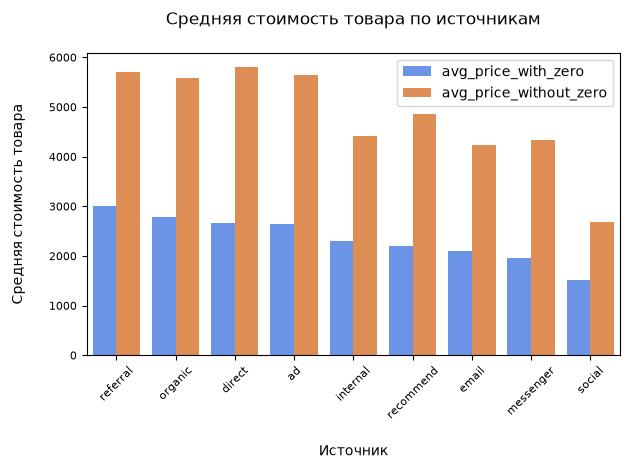

In [63]:
# Вывод графиков
avg_long = avg_merged.melt(
    id_vars='lastsignTrafficSource',
    var_name='Тип расчета',
    value_name='Средняя стоимость'
)

sns.barplot(
    data=avg_long,
    x='lastsignTrafficSource',
    y='Средняя стоимость',
    hue='Тип расчета'
)

plt.xlabel('\nИсточник')
plt.ylabel('Средняя стоимость товара\n')
plt.title('Средняя стоимость товара по источникам\n')
plt.xticks(rotation=45)
plt.legend(title='')

plt.tight_layout()
plt.show()

Вывод: исключение нулевых цен существенно повышает среднюю стоимость товара по всем источникам, что означает, что нулевые значения заметно искажают среднее. Однако без дополнительной информации нельзя однозначно считать их ошибочными, так как они могут соответствовать подарочным, бонусным или иным позициям

#### *(Усложнённая задача) Преобразуйте необработанные данные из источников raw_purchases.csv и raw_products.csv в вид, соответствующий исходным данным для задания.

In [64]:
raw_products = pd.read_csv('raw_products.csv')
raw_products

,productsPurchaseID,productsID,productsPrice
0,"['60323068','60323068']","['58627','137958']","[4590000000,0]"
1,"['60324684','60324684']","['28543','137958']","[3391000000,0]"
2,"['60329108','60329103']","['1921','1921']","[16310000000,16310000000]"
3,['60326705'],['140727'],[5550000000]
4,"['60330472','60330472','60330472','60330472','...","['18636','286864','137958','294093','292915']","[12190000000,0,0,0,0]"
...,...,...,...
5797,"['60332870','60332870','60332870','60332870']","['128182','149082','147510','76768']","[1417000000,0,0,3019000000]"
5798,['60335643'],['109840'],[9900000000]
5799,"['60330154','60330154','60330154']","['50145','124930','137958']","[4420000000,540000000,0]"
5800,['60323344'],['146919'],[972000000]


превратим каждый элемент списка в отдельную строку, приведем в норму цены, поделив их на 1.000.000

In [65]:
raw_purchases = pd.read_csv('raw_purchases.csv')
raw_purchases

,lastsignTrafficSource,purchaseID,purchaseRevenue,purchaseDateTime
0,organic,['60337498'],[2845.0],[\'2025-05-27 10:19:03\']
1,organic,['60335988'],[7830.0],[\'2025-05-24 16:30:01\']
2,ad,['60334562'],[9319.0],[\'2025-05-22 01:59:54\']
3,direct,"['60336983','60336989']","[6889.0,4549.0]","[\'2025-05-26 12:11:20\',\'2025-05-26 12:16:08\']"
4,organic,['60327247'],[3400.0],[\'2025-05-11 09:50:52\']
...,...,...,...,...
5797,ad,['60332870'],[4436.0],[\'2025-05-19 10:53:39\']
5798,referral,['60335643'],[9900.0],[\'2025-05-23 20:13:04\']
5799,ad,['60330154'],[4960.0],[\'2025-05-14 23:26:30\']
5800,ad,['60323344'],[1172.0],[\'2025-05-04 20:27:56\']


In [85]:
purchases_clean = raw_purchases.copy()

In [86]:
purchases_clean['purchaseID'] = purchases_clean['purchaseID'].apply(ast.literal_eval)

purchases_clean['purchaseRevenue'] = purchases_clean['purchaseRevenue'].apply(ast.literal_eval)

purchases_clean.head()

,lastsignTrafficSource,purchaseID,purchaseRevenue,purchaseDateTime
0,organic,[60337498],[2845.0],[\'2025-05-27 10:19:03\']
1,organic,[60335988],[7830.0],[\'2025-05-24 16:30:01\']
2,ad,[60334562],[9319.0],[\'2025-05-22 01:59:54\']
3,direct,"[60336983, 60336989]","[6889.0, 4549.0]","[\'2025-05-26 12:11:20\',\'2025-05-26 12:16:08\']"
4,organic,[60327247],[3400.0],[\'2025-05-11 09:50:52\']


In [87]:
purchases_clean['purchaseDateTime'] = (purchases_clean['purchaseDateTime'].str.replace("\\'", "'", regex=False).apply(ast.literal_eval))

In [90]:
purchases_clean = purchases_clean.explode(['purchaseID', 'purchaseRevenue', 'purchaseDateTime'], ignore_index=True)
# применяем три столбца сразу чтоб значения не потеряли соответствие

purchases_clean['purchaseID'] = pd.to_numeric(purchases_clean['purchaseID'])

purchases_clean['purchaseRevenue'] = pd.to_numeric(purchases_clean['purchaseRevenue'])

purchases_clean['purchaseDateTime'] = pd.to_datetime(purchases_clean['purchaseDateTime'])

In [91]:
purchases_clean

,lastsignTrafficSource,purchaseID,purchaseRevenue,purchaseDateTime
0,organic,60337498,2845.0,2025-05-27 10:19:03
1,organic,60335988,7830.0,2025-05-24 16:30:01
2,ad,60334562,9319.0,2025-05-22 01:59:54
3,direct,60336983,6889.0,2025-05-26 12:11:20
4,direct,60336989,4549.0,2025-05-26 12:16:08
...,...,...,...,...
6457,ad,60332870,4436.0,2025-05-19 10:53:39
6458,referral,60335643,9900.0,2025-05-23 20:13:04
6459,ad,60330154,4960.0,2025-05-14 23:26:30
6460,ad,60323344,1172.0,2025-05-04 20:27:56


In [97]:
products_clean = raw_products.copy()

products_clean['productsPurchaseID'] = products_clean['productsPurchaseID'].apply(ast.literal_eval)
products_clean['productsID'] = products_clean['productsID'].apply(ast.literal_eval)
products_clean['productsPrice'] = products_clean['productsPrice'].apply(ast.literal_eval)

products_clean = products_clean.explode(['productsPurchaseID', 'productsID', 'productsPrice'], ignore_index=True)

products_clean['productsPurchaseID'] = pd.to_numeric(products_clean['productsPurchaseID'])
products_clean['productsID'] = pd.to_numeric(products_clean['productsID'])
products_clean['productsPrice'] = pd.to_numeric(products_clean['productsPrice'])

products_clean

,productsPurchaseID,productsID,productsPrice
0,60323068,58627,4590000000
1,60323068,137958,0
2,60324684,28543,3391000000
3,60324684,137958,0
4,60329108,1921,16310000000
...,...,...,...
20764,60327669,289514,324000000
20765,60327669,286864,0
20766,60327669,137958,0
20767,60327669,294093,0


In [98]:
products_clean['productsPrice'] = (products_clean['productsPrice'] / 1000000)

products_clean.head()

,productsPurchaseID,productsID,productsPrice
0,60323068,58627,4590.0
1,60323068,137958,0.0
2,60324684,28543,3391.0
3,60324684,137958,0.0
4,60329108,1921,16310.0


In [103]:
products_clean.shape, products.shape

((20769, 3), (20769, 3))

In [104]:
purchases_clean.shape, purchases.shape

((6462, 4), (6462, 5))

тадам